In [1]:
import pandas as pd
import time
from sklearn.metrics import (recall_score, precision_score, f1_score, 
                             accuracy_score, roc_auc_score, average_precision_score, 
                             confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import MiniBatchKMeans
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN, RandomOverSampler
from sklearn.preprocessing import RobustScaler
import seaborn as sns
import matplotlib.pyplot as plt

## Opis kroków przeprowadzonych podczas estymacji oraz walidacji modelu Lasów Losowych:
### Wczytanie danych
Dane na których został wytrenowany oraz zwalidowany model Lasów Losowych to dane, dla których została przeprowadzaona Ekspolarcyjna Analiza Danych oraz Inżynieria Cech w Notebooku `00_EAD`.
Wczytane dane zostały już wcześniej podzielone na zbiór treningowy oraz testowy w proporcji 30/70.

### Transformacja danych
Następnie została przeprowadzona transformacja danych:
- One-Hot Encoding: zmienna określająca rodzaj transakcji `type` jest zmienną kategoryczną. Z technicznego punktu widzenia model Random Foret z biblioteki `scikit-learn` wymaga danych numeryczny. Natomiast wykorzystane w badaniu samplery opare są na odległościach, zatem w ich przypadku również wymagane są dane numeryczne. 
- RobustScaler: podobnie jak w przypadku zastosowania metody One-Hot Encoding, samplery oprate na odległości wymagają danych, które mają taką samą skale.
Jako skaler użyto RobustSkaler, który jest bardziej odporny na wartości odstające, które występują w danych finansowych. Został on zastosowany do wszystkich kolumn, poza kolumnami 0/1.
W przypadku modelu Lasów Losowych skalowanie danych nie wpływa w żaden sposób na jego estymowanie.

$$X_{scaled} = \frac{X - \text{median}(X)}{IQR(X)} = \frac{X - \text{median}(X)}{Q_3(X) - Q_1(X)}$$

* $\text{median}(X)$ – medianę dla danej cechy wyliczoną z całego zbioru treningowego.
* $IQR(X)$ – rozstęp międzykwartylowy, będący miarą rozproszenia danych.
* $Q_1(X)$ – pierwszy kwartyl,
* $Q_3(X)$ – trzeci kwartyl,

### Słownik sampletrów
W następnym bloku zdefiniowano słownik `samplers` przygotowujący środowisko do eksperymentów z balansowaniem klas. 
Skrypt iteracyjnie generuje zestaw obejmujący wariant bazowy oraz 6 algorytmów: RandomUnderSampler, Cluster Centroids, RandomOverSampler, SMOTE, Borderline-SMOTE, ADASYN. 
Każda z metod jest inicjalizowana dla 4 różnych docelowych proporcji klasy mniejszościowej: 0.25, 0.50, 0.75 oraz 1.0.

### Główna pętla
Finalnie uruchamiana jest główna pętla eksperymentu. 
Kod iteruje przez zdefiniowany wcześniej słownik samplerów, przekształcając zbiór treningowy i trenując na nim standardowy model Lasów Losowych.
Następnie trenowany jest osobny model wykorzystujący wbudowane ważenie klas `class_weight='balanced'`, testując podejście na poziomie algorytmu. 
Dla każdego wariantu obliczane są kluczowe metryki na zbiorze treningowym jak i testowym.

### Analiza przesunięcia ważności cech
Następnie została przprowadzona analiza ważności cech dla wybranych metod. 

### Wczytanie danych

In [2]:
X_train = pd.read_parquet('gotowe_dane/X_train.parquet')
X_test = pd.read_parquet('gotowe_dane/X_test.parquet')
y_train = pd.read_parquet('gotowe_dane/y_train.parquet')['isFraud']
y_test = pd.read_parquet('gotowe_dane/y_test.parquet')['isFraud']
print(f"Kształt zbioru treningowego: {X_train.shape}")

Kształt zbioru treningowego: (4453834, 7)


### Transformacja danych

In [3]:
# One-Hot Encoding dla kolumny kategorycznej
X_train_ohe = pd.get_dummies(X_train, columns=['type'], drop_first=True, dtype=int)
X_test_ohe = pd.get_dummies(X_test, columns=['type'], drop_first=True, dtype=int)

# Zbieramy kolumny numeryczne
num_cols = [col for col in X_train.columns if col != 'type']

X_train_scaled = X_train_ohe.copy()
X_test_scaled = X_test_ohe.copy()

# RobustScaler tylko na kolumnach numerycznych, z pominięciem kolumn 0/1
scaler = RobustScaler()
X_train_scaled[num_cols] = scaler.fit_transform(X_train_ohe[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_ohe[num_cols])

### Definiowanie słownika samplerów

In [4]:
proporcje = [0.25, 0.5, 0.75, 1.0]
samplers = {'Model bazowy' : None}

for p in proporcje:
    nazwa_p = str(p)
    samplers[f'RUS ({nazwa_p})'] = RandomUnderSampler(sampling_strategy=p, random_state=42)
    samplers[f'ROS ({nazwa_p})'] = RandomOverSampler(sampling_strategy=p, random_state=42)
    samplers[f'SMOTE ({nazwa_p})'] = SMOTE(sampling_strategy=p, random_state=42)
    samplers[f'Borderline-SMOTE ({nazwa_p})'] = BorderlineSMOTE(sampling_strategy=p, random_state=42)
    samplers[f'ADASYN ({nazwa_p})'] = ADASYN(sampling_strategy=p, random_state=42)
    
    samplers[f'Cluster Centroids ({nazwa_p})'] = ClusterCentroids(
        sampling_strategy=p,
        estimator=MiniBatchKMeans(n_init=1, random_state=42), 
        random_state=42
    )

### Główna pętla

In [5]:
base_params = {
    'n_estimators': 100,
    'max_depth': 20,           
    'min_samples_leaf': 10,    
    'n_jobs': -1,              
    'random_state': 42
}

model_standard = RandomForestClassifier(**base_params)
model_weighted = RandomForestClassifier(**base_params, class_weight='balanced_subsample')

results_test = []
results_train = [] # Dodana osobna lista dla wyników treningowych
print("\n--- ROZPOCZĘCIE EKSPERYMENTU: RANDOM FOREST ---")

for s_name, sampler in samplers.items():
    print(f" -> Trenuję: RF + {s_name}")
    
    # timer dla samplera
    start_sampler = time.time()
    if sampler:
        X_res, y_res = sampler.fit_resample(X_train_scaled, y_train)
    else:
        X_res, y_res = X_train_scaled, y_train
        
    end_sampler = time.time()
    czas_samplera = end_sampler - start_sampler
    
    # timer dla modelu
    start_model = time.time()
    model_standard.fit(X_res, y_res)
    end_model = time.time()
    czas_modelu = end_model - start_model
    
    czas_calkowity = czas_samplera + czas_modelu

    # ZBIÓR TESTOWY
    preds_test = model_standard.predict(X_test_scaled)
    preds_proba_test = model_standard.predict_proba(X_test_scaled)[:, 1]
    tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, preds_test).ravel()
    
    # ZBIÓR TRENINGOWY
    preds_train = model_standard.predict(X_train_scaled)
    preds_proba_train = model_standard.predict_proba(X_train_scaled)[:, 1]
    tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, preds_train).ravel()

    # ZAPIS DO TABELI TESTOWEJ
    results_test.append({
        'Podejście': 'Data-Level',
        'Metoda': s_name,
        'Czas Samplera (s)': round(czas_samplera, 2),
        'Czas Modelu (s)': round(czas_modelu, 2),
        'Czas Całkowity (s)': round(czas_calkowity, 2),
        'Recall (Czułość)': recall_score(y_test, preds_test),
        'Precision': precision_score(y_test, preds_test),
        'F1-Score': f1_score(y_test, preds_test),
        'ROC-AUC': roc_auc_score(y_test, preds_proba_test),
        'PR-AUC': average_precision_score(y_test, preds_proba_test),
        'Accuracy': accuracy_score(y_test, preds_test),
        'FP (Fałszywe Alarmy)': fp_test,
        'FN (Przegapione)': fn_test
    })

    # ZAPIS DO TABELI TRENINGOWEJ
    results_train.append({
        'Podejście': 'Data-Level',
        'Metoda': s_name,
        'Czas Samplera (s)': round(czas_samplera, 2),
        'Czas Modelu (s)': round(czas_modelu, 2),
        'Czas Całkowity (s)': round(czas_calkowity, 2),
        'Recall (Czułość)': recall_score(y_train, preds_train),
        'Precision': precision_score(y_train, preds_train),
        'F1-Score': f1_score(y_train, preds_train),
        'ROC-AUC': roc_auc_score(y_train, preds_proba_train),
        'PR-AUC': average_precision_score(y_train, preds_proba_train),
        'Accuracy': accuracy_score(y_train, preds_train),
        'FP (Fałszywe Alarmy)': fp_train,
        'FN (Przegapione)': fn_train
    })

# wewnętrzne ważenie klas
print(" -> Trenuję: RF + class_weight='balanced_subsample'")

czas_samplera_w = 0.0

# timer dla modelu
start_model_w = time.time()
model_weighted.fit(X_train_scaled, y_train)
end_model_w = time.time()
czas_modelu_w = end_model_w - start_model_w
czas_calkowity_w = czas_samplera_w + czas_modelu_w

# ZBIÓR TESTOWY
preds_test_w = model_weighted.predict(X_test_scaled)
preds_proba_test_w = model_weighted.predict_proba(X_test_scaled)[:, 1]
tn_test_w, fp_test_w, fn_test_w, tp_test_w = confusion_matrix(y_test, preds_test_w).ravel()

# ZBIÓR TRENINGOWY
preds_train_w = model_weighted.predict(X_train_scaled)
preds_proba_train_w = model_weighted.predict_proba(X_train_scaled)[:, 1]
tn_train_w, fp_train_w, fn_train_w, tp_train_w = confusion_matrix(y_train, preds_train_w).ravel()

results_test.append({
    'Podejście': 'Algorithm-Level',
    'Metoda': 'Wewnętrzne Wagi (balanced_subsample)',
    'Czas Samplera (s)': round(czas_samplera_w, 2),
    'Czas Modelu (s)': round(czas_modelu_w, 2),
    'Czas Całkowity (s)': round(czas_calkowity_w, 2),
    'Recall (Czułość)': recall_score(y_test, preds_test_w),
    'Precision': precision_score(y_test, preds_test_w),
    'F1-Score': f1_score(y_test, preds_test_w),
    'ROC-AUC': roc_auc_score(y_test, preds_proba_test_w),
    'PR-AUC': average_precision_score(y_test, preds_proba_test_w),
    'Accuracy': accuracy_score(y_test, preds_test_w),
    'FP (Fałszywe Alarmy)': fp_test_w,
    'FN (Przegapione)': fn_test_w
})

results_train.append({
    'Podejście': 'Algorithm-Level',
    'Metoda': 'Wewnętrzne Wagi (balanced_subsample)',
    'Czas Samplera (s)': round(czas_samplera_w, 2),
    'Czas Modelu (s)': round(czas_modelu_w, 2),
    'Czas Całkowity (s)': round(czas_calkowity_w, 2),
    'Recall (Czułość)': recall_score(y_train, preds_train_w),
    'Precision': precision_score(y_train, preds_train_w),
    'F1-Score': f1_score(y_train, preds_train_w),
    'ROC-AUC': roc_auc_score(y_train, preds_proba_train_w),
    'PR-AUC': average_precision_score(y_train, preds_proba_train_w),
    'Accuracy': accuracy_score(y_train, preds_train_w),
    'FP (Fałszywe Alarmy)': fp_train_w,
    'FN (Przegapione)': fn_train_w
})

print("\n--- ZAKOŃCZONO ---")

results_df_train = pd.DataFrame(results_train)
results_df_test = pd.DataFrame(results_test)

nazwa_pliku_train = 'wyniki_random_forest_train.csv'
nazwa_pliku_test = 'wyniki_random_forest_test.csv'

results_df_train.to_csv(nazwa_pliku_train, index=False)
results_df_test.to_csv(nazwa_pliku_test, index=False)

print(f"Wyniki treningowe zostały pomyślnie zapisane do pliku: {nazwa_pliku_train}")
print(f"Wyniki testowe zostały pomyślnie zapisane do pliku: {nazwa_pliku_test}")


--- ROZPOCZĘCIE EKSPERYMENTU: RANDOM FOREST ---
 -> Trenuję: RF + Model bazowy
 -> Trenuję: RF + RUS (0.25)
 -> Trenuję: RF + ROS (0.25)
 -> Trenuję: RF + SMOTE (0.25)
 -> Trenuję: RF + Borderline-SMOTE (0.25)
 -> Trenuję: RF + ADASYN (0.25)
 -> Trenuję: RF + Cluster Centroids (0.25)
 -> Trenuję: RF + RUS (0.5)
 -> Trenuję: RF + ROS (0.5)
 -> Trenuję: RF + SMOTE (0.5)
 -> Trenuję: RF + Borderline-SMOTE (0.5)
 -> Trenuję: RF + ADASYN (0.5)
 -> Trenuję: RF + Cluster Centroids (0.5)
 -> Trenuję: RF + RUS (0.75)
 -> Trenuję: RF + ROS (0.75)
 -> Trenuję: RF + SMOTE (0.75)
 -> Trenuję: RF + Borderline-SMOTE (0.75)
 -> Trenuję: RF + ADASYN (0.75)
 -> Trenuję: RF + Cluster Centroids (0.75)
 -> Trenuję: RF + RUS (1.0)
 -> Trenuję: RF + ROS (1.0)
 -> Trenuję: RF + SMOTE (1.0)
 -> Trenuję: RF + Borderline-SMOTE (1.0)
 -> Trenuję: RF + ADASYN (1.0)
 -> Trenuję: RF + Cluster Centroids (1.0)
 -> Trenuję: RF + class_weight='balanced_subsample'

--- ZAKOŃCZONO ---
Wyniki treningowe zostały pomyślnie 

In [6]:
display(results_df_train)

,Podejście,Metoda,Czas Samplera (s),Czas Modelu (s),Czas Całkowity (s),Recall (Czułość),Precision,F1-Score,ROC-AUC,PR-AUC,Accuracy,FP (Fałszywe Alarmy),FN (Przegapione)
0,Data-Level,Model bazowy,0.00,177.66,177.66,0.992520,0.998775,0.995638,1.000000,0.999884,0.999989,7,43
1,Data-Level,RUS (0.25),0.88,0.48,1.35,0.993738,0.982628,0.988152,0.999977,0.997311,0.999969,101,36
2,Data-Level,ROS (0.25),1.84,214.11,215.95,1.000000,0.997225,0.998610,1.000000,1.000000,0.999996,16,0
3,Data-Level,SMOTE (0.25),0.96,107.46,108.42,0.996173,0.997735,0.996954,1.000000,0.999777,0.999992,13,22
4,Data-Level,Borderline-SMOTE (0.25),4.90,112.88,117.79,0.993390,0.998252,0.995815,1.000000,0.999883,0.999989,10,38
5,Data-Level,ADASYN (0.25),4.87,108.91,113.78,0.995999,0.997909,0.996953,1.000000,0.999794,0.999992,12,23
6,Data-Level,Cluster Centroids (0.25),248.60,0.28,248.89,0.993738,0.991496,0.992616,0.999980,0.997423,0.999981,49,36
7,Data-Level,RUS (0.5),0.61,0.17,0.78,0.995130,0.926478,0.959577,0.999949,0.996710,0.999892,454,28
8,Data-Level,ROS (0.5),1.15,121.73,122.88,1.000000,0.998264,0.999131,1.000000,1.000000,0.999998,10,0
9,Data-Level,SMOTE (0.5),1.04,137.81,138.85,0.996347,0.997214,0.996781,1.000000,0.999760,0.999992,16,21


In [7]:
display(results_df_test)

,Podejście,Metoda,Czas Samplera (s),Czas Modelu (s),Czas Całkowity (s),Recall (Czułość),Precision,F1-Score,ROC-AUC,PR-AUC,Accuracy,FP (Fałszywe Alarmy),FN (Przegapione)
0,Data-Level,Model bazowy,0.00,177.66,177.66,0.993101,0.999592,0.996336,0.999183,0.996621,0.999991,1,17
1,Data-Level,RUS (0.25),0.88,0.48,1.35,0.995536,0.986329,0.990911,0.999609,0.997109,0.999976,34,11
2,Data-Level,ROS (0.25),1.84,214.11,215.95,0.996347,0.997967,0.997157,0.998922,0.996550,0.999993,5,9
3,Data-Level,SMOTE (0.25),0.96,107.46,108.42,0.996347,0.999593,0.997967,0.999347,0.996598,0.999995,1,9
4,Data-Level,Borderline-SMOTE (0.25),4.90,112.88,117.79,0.993506,1.000000,0.996743,0.999192,0.996370,0.999992,0,16
5,Data-Level,ADASYN (0.25),4.87,108.91,113.78,0.995942,0.999186,0.997561,0.999118,0.996368,0.999994,2,10
6,Data-Level,Cluster Centroids (0.25),248.60,0.28,248.89,0.995536,0.990311,0.992916,0.999577,0.997024,0.999982,24,11
7,Data-Level,RUS (0.5),0.61,0.17,0.78,0.996347,0.926765,0.960297,0.999627,0.996898,0.999894,194,9
8,Data-Level,ROS (0.5),1.15,121.73,122.88,0.996347,0.999593,0.997967,0.999186,0.996752,0.999995,1,9
9,Data-Level,SMOTE (0.5),1.04,137.81,138.85,0.996347,0.999593,0.997967,0.999381,0.996494,0.999995,1,9


### Analiza przesunięcia ważności cech

Wybieramy SMOTE (0.25), RUS (1.0), Borderline Smote (0.25) oraz do porównania model bazowy i wewnętrzne ważenie klas, tak aby porównać najlepsze metody nadpróbkowywania oraz podpróbkowywania danych. 

In [8]:
# SMOTE (0.25)
smote_plot = SMOTE(sampling_strategy=0.25, random_state=42)
X_res_smote, y_res_smote = smote_plot.fit_resample(X_train_scaled, y_train)

# RUS (1.0)
rus_plot = RandomUnderSampler(sampling_strategy=1.0, random_state=42)
X_res_rus, y_res_rus = rus_plot.fit_resample(X_train_scaled, y_train)

# Borderline Smote (0.25)
borderline_smote_plot = BorderlineSMOTE(sampling_strategy=0.25, random_state=42)
X_res_bs, y_res_bs = borderline_smote_plot.fit_resample(X_train_scaled, y_train)

# Trening modeli 
# Baseline
rf_baseline = RandomForestClassifier(n_estimators=100, max_depth=20, n_jobs=-1, random_state=42)
# SMOTE
rf_smote = RandomForestClassifier(n_estimators=100, max_depth=20, n_jobs=-1, random_state=42)
# RUS
rf_rus = RandomForestClassifier(n_estimators=100, max_depth=20, n_jobs=-1, random_state=42)
# Borderline Smote
rf_borderline_smote = RandomForestClassifier(n_estimators=100, max_depth=20, n_jobs=-1, random_state=42)
# Wewnętrzne wagi
rf_weighted = RandomForestClassifier(n_estimators=100, max_depth=20, class_weight='balanced_subsample', n_jobs=-1, random_state=42)

# Trenowanie
rf_baseline.fit(X_train_scaled, y_train)
rf_smote.fit(X_res_smote, y_res_smote)
rf_rus.fit(X_res_rus, y_res_rus)
rf_borderline_smote.fit(X_res_bs, y_res_bs)
rf_weighted.fit(X_train_scaled, y_train)


RandomForestClassifier(class_weight='balanced_subsample', max_depth=20,
                       n_jobs=-1, random_state=42)

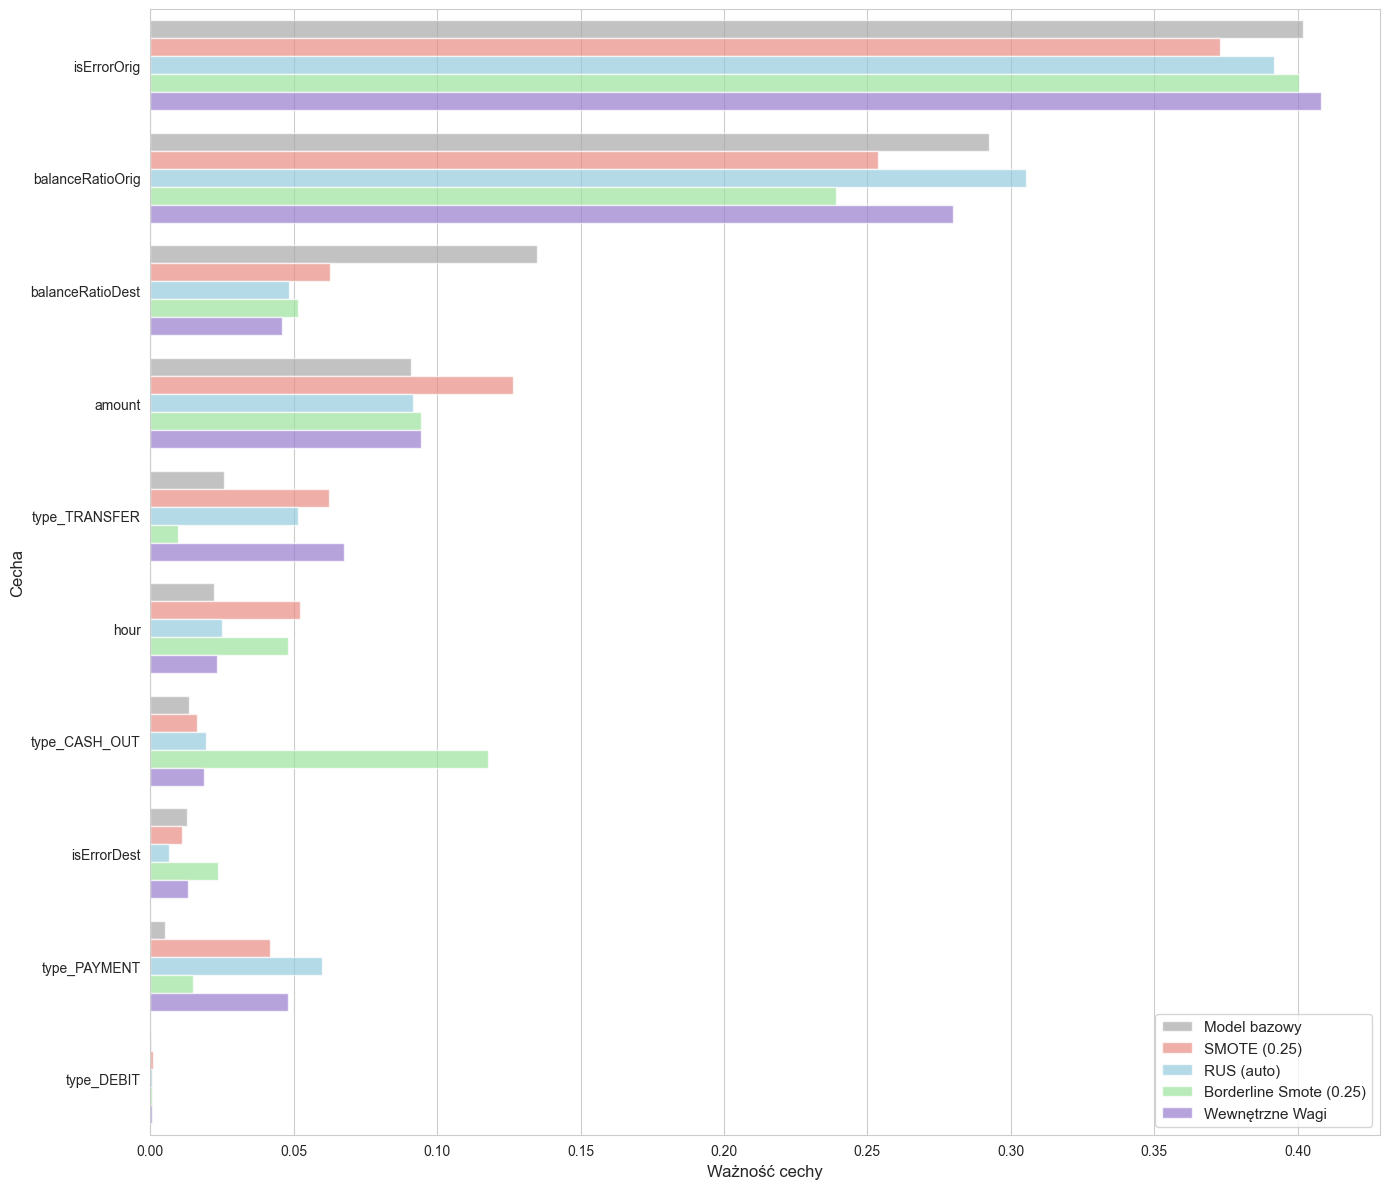

In [9]:
nazwy_cech = X_train_scaled.columns 

df_importance = pd.DataFrame({
    'Cecha': nazwy_cech,
    'Model bazowy': rf_baseline.feature_importances_,
    'SMOTE (0.25)': rf_smote.feature_importances_,
    'RUS (auto)': rf_rus.feature_importances_,
    'Borderline Smote (0.25)': rf_borderline_smote.feature_importances_,
    'Wewnętrzne Wagi': rf_weighted.feature_importances_
})


df_melted = df_importance.melt(id_vars='Cecha', var_name='Model', value_name='Ważność')
cechy_posortowane = df_importance.sort_values(by='Model bazowy', ascending=False)['Cecha']


sns.set_style("whitegrid")
plt.figure(figsize=(14, 12)) 

ax = sns.barplot(
    data=df_melted,
    x='Ważność',
    y='Cecha',
    hue='Model',
    order=cechy_posortowane,
    palette=['darkgray', 'salmon', 'skyblue', 'lightgreen', 'mediumpurple'], 
    alpha=0.7 
)

plt.xlabel('Ważność cechy', fontsize=12)
plt.ylabel('Cecha', fontsize=12)
plt.legend(fontsize=11, title_fontsize=12, loc='lower right')
plt.tight_layout()
plt.show()